Check CUDA version and that GPU is working in cellpose and import other libraries.

In [1]:
!nvcc --version
!nvidia-smi

import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from cellpose import core, utils, io, models, metrics
from glob import glob

use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

/bin/bash: nvcc: command not found
Tue Jun 18 12:35:42 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A6000               On  | 00000000:1A:00.0 Off |                  Off |
| 30%   33C    P8              23W / 300W |    271MiB / 49140MiB |      0%      Default |
|                                         |                      |                  N/A |
+--------------------------------

In [2]:
import skimage.io

# read the image

DIRECTORY = "/home/MORGRIDGE/vagrawal/vidit/dataset_v2"
files = os.listdir("/home/MORGRIDGE/vagrawal/vidit/dataset_v2")
filelist = [file for file in files if not file.startswith('.')]
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

ground_truth_images = []
phenotype_images = []

for i in annot_files:
    ground_truth_images.append(DIRECTORY + '/' + i.replace('phenotype_outlines.png', 'phenotype.tif'))
    phenotype_images.append(DIRECTORY + '/' + i.replace('phenotype_outlines.png', 'nuclei-clean.tif'))

print(ground_truth_images)
print(phenotype_images)


['/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-10.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-110.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-130.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-150.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-170.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-190.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-30.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-50.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-70.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-90.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype.tif

In [4]:
#copy images to another folder

for i in range(len(ground_truth_images)):
    shutil.copy(ground_truth_images[i], '/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train')
    shutil.copy(phenotype_images[i], '/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train')

## Training parameters

<font size = 4> **Paths for training, predictions and results**


<font size = 4>**`train_dir:`, `test_dir`:** These are the paths to your folders train_dir (with images and masks of training images) and test_dir (with images and masks of test images). You can leave the test_dir blank, but it's recommended to have some test images to check the model's performance. To find the paths of the folders containing the respective datasets, go to your Files on the left of the notebook, navigate to the folder containing your files and copy the path by right-clicking on the folder, **Copy path** and pasting it into the right box below.

<font size = 4>**`initial_model`:** Choose a model from the cellpose [model zoo](https://cellpose.readthedocs.io/en/latest/models.html#model-zoo) to start from.

<font size = 4>**`model_name`**: Enter the path where your model will be saved once trained (for instance your result folder).

<font size = 4>**Training parameters**

<font size = 4>**`number_of_epochs`:** Input how many epochs (rounds) the network will be trained. At least 100 epochs are recommended, but sometimes 250 epochs are necessary, particularly from scratch. **Default value: 100**



In [5]:
#@markdown ###Path to images and masks:

train_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train" #@param {type:"string"}
test_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test" #@param {type:"string"}
#Define where the patch file will be saved
base = "/content"

# model name and path
#@markdown ###Name of the pretrained model to start from and new model name:
from cellpose import models
initial_model = "cyto" #@param ["cyto", "cyto3","nuclei","tissuenet_cp3", "livecell_cp3", "yeast_PhC_cp3", "yeast_BF_cp3", "bact_phase_cp3", "bact_fluor_cp3", "deepbacs_cp3", "scratch"]
model_name = "CP_tissuenet" #@param {type:"string"}

# other parameters for training.
#@markdown ###Training Parameters:
#@markdown Number of epochs:
n_epochs =  100#@param {type:"number"}

Channel_to_use_for_training = "Grayscale" #@param ["Grayscale", "Blue", "Green", "Red"]

# @markdown ###If you have a secondary channel that can be used for training, for instance nuclei, choose it here:

Second_training_channel= "None" #@param ["None", "Blue", "Green", "Red"]


#@markdown ###Advanced Parameters

Use_Default_Advanced_Parameters = True #@param {type:"boolean"}
#@markdown ###If not, please input:
learning_rate = 0.1 #@param {type:"number"}
weight_decay = 0.0001 #@param {type:"number"}

if (Use_Default_Advanced_Parameters):
  print("Default advanced parameters enabled")
  learning_rate = 0.1
  weight_decay = 0.0001

#here we check that no model with the same name already exist, if so delete
model_path = train_dir + 'models/'
if os.path.exists(model_path+'/'+model_name):
  print("!! WARNING: "+model_name+" already exists and will be deleted in the following cell !!")

if len(test_dir) == 0:
  test_dir = None

# Here we match the channel to number
if Channel_to_use_for_training == "Grayscale":
  chan = 0
elif Channel_to_use_for_training == "Blue":
  chan = 3
elif Channel_to_use_for_training == "Green":
  chan = 2
elif Channel_to_use_for_training == "Red":
  chan = 1


if Second_training_channel == "Blue":
  chan2 = 3
elif Second_training_channel == "Green":
  chan2 = 2
elif Second_training_channel == "Red":
  chan2 = 1
elif Second_training_channel == "None":
  chan2 = 0

if initial_model=='scratch':
  initial_model = 'None'

Default advanced parameters enabled


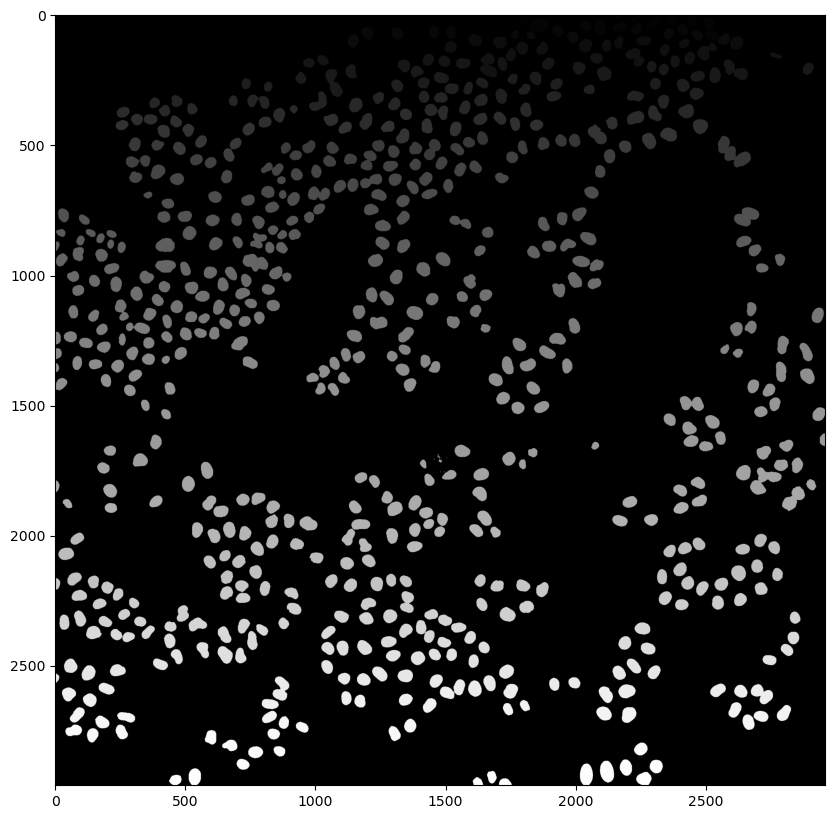

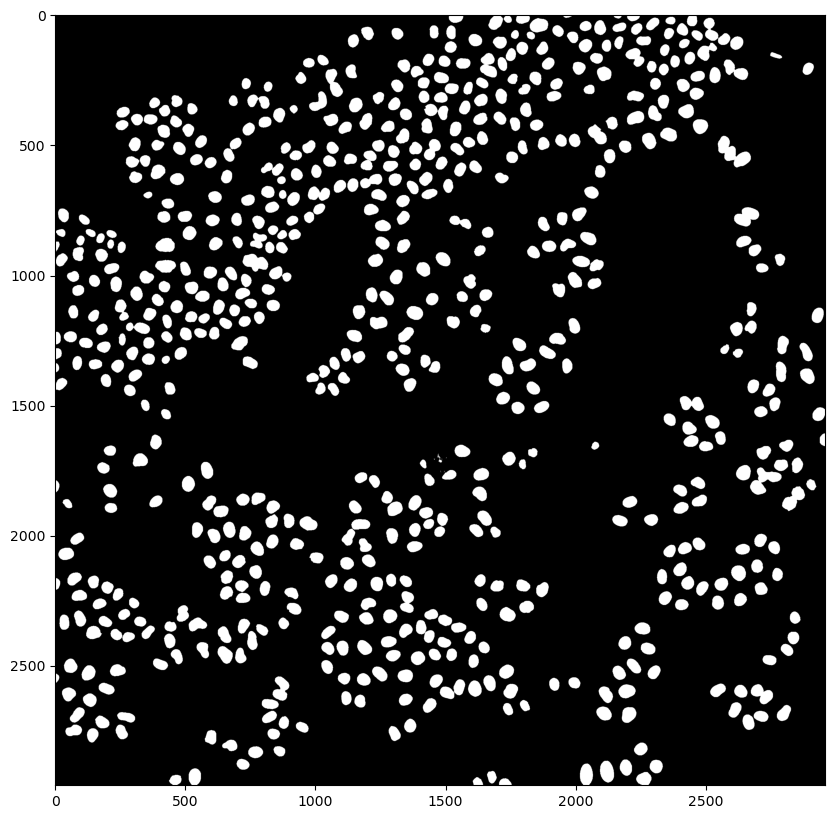

In [11]:
#Display the .tif images in the folder
file_path = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train/20X_c0-DAPI_A1_Tile-10.nuclei-clean.tif"

img = skimage.io.imread(file_path)
plt.figure(figsize=(10,10))
plt.imshow(img, cmap='gray')
#Convert this into a probability map making white as 1 and black as 0. Save it as a _seg.npy file
plt.figure(figsize=(10,10))
plt.imshow(img>0, cmap='gray')
plt.show()

#Save the probability map
seg = img>0
np.save(file_path.replace('.tif', '_seg.npy'), seg)



Here's what the command to train would be on the command line -- make sure if you run this locally to correct the paths for your local computer.

In [7]:
run_str = f'python -m cellpose --use_gpu --verbose --train --dir {train_dir} --pretrained_model {initial_model} --chan {chan} --chan2 {chan2} --n_epochs {n_epochs} --learning_rate {learning_rate} --weight_decay {weight_decay}'
if test_dir is not None:
    run_str += f' --test_dir {test_dir}'
run_str += ' --mask_filter _seg.npy' # if you want to use _seg.npy files for training
print(run_str)

python -m cellpose --use_gpu --verbose --train --dir /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train --pretrained_model cyto --chan 0 --chan2 0 --n_epochs 100 --learning_rate 0.1 --weight_decay 0.0001 --test_dir /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test --mask_filter _seg.npy


In [9]:
!python -m cellpose --use_gpu --verbose --train --dir /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train --pretrained_model cyto --chan 0 --chan2 0 --n_epochs 100 --learning_rate 0.1 --weight_decay 0.0001 --test_dir /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test --mask_filter _seg.npy

2024-06-18 13:30:29,699 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/vagrawal/.cellpose/run.log
2024-06-18 13:30:29,699 [INFO] 
cellpose version: 	3.0.9 
platform:       	linux 
python version: 	3.11.0 
torch version:  	2.3.0
2024-06-18 13:30:29,929 [INFO] ** TORCH CUDA version installed and working. **
2024-06-18 13:30:29,929 [INFO] >>>> using GPU
2024-06-18 13:30:29,933 [INFO] not all flows are present, running flow generation for all images
2024-06-18 13:30:29,933 [INFO] 0 / 36 images in /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train folder have labels
2024-06-18 13:30:29,933 [INFO] not all flows are present, running flow generation for all images
2024-06-18 13:30:29,933 [INFO] 0 / 2 images in /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test folder have labels
2024-06-18 13:30:29,933 [INFO] >>>> during training rescaling images to fixed diameter of 30.0 pixels
2024-06-18 13:30:29,934 [INFO] >> cyto << model set to be used
2024-06-18 13:30:29,999 [INFO] >>>> loading model /hom

## Train new model

Using settings from form above, train model in notebook.

In [8]:
from cellpose import train

# start logger (to see training across epochs)
logger = io.logger_setup()

# DEFINE CELLPOSE MODEL (without size model)
model = models.CellposeModel(gpu=use_GPU, model_type=initial_model)

# set channels
channels = [0, 0]

# get files
output = io.load_train_test_data(train_dir, test_dir, mask_filter='_seg.npy')
train_data, train_labels, _, test_data, test_labels, _ = output

new_model_path = train.train_seg(model.net, train_data=train_data,
                              train_labels=train_labels,
                              test_data=test_data,
                              test_labels=test_labels,
                              channels=channels,
                              save_path=train_dir,
                              n_epochs=n_epochs,
                              learning_rate=learning_rate,
                              weight_decay=weight_decay,
                              SGD=True,
                              nimg_per_epoch=8,
                              model_name=model_name)

# diameter of labels in training images
diam_labels = model.net.diam_labels.item()

creating new log file
2024-06-18 13:29:38,118 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/vagrawal/.cellpose/run.log
2024-06-18 13:29:38,119 [INFO] 
cellpose version: 	3.0.9 
platform:       	linux 
python version: 	3.11.0 
torch version:  	2.3.0
2024-06-18 13:29:38,119 [INFO] >> cyto << model set to be used
2024-06-18 13:29:38,120 [INFO] Downloading: "https://www.cellpose.org/models/cytotorch_0" to /home/MORGRIDGE/vagrawal/.cellpose/models/cytotorch_0



100%|██████████| 25.3M/25.3M [00:00<00:00, 76.1MB/s]

2024-06-18 13:29:38,729 [INFO] ** TORCH CUDA version installed and working. **
2024-06-18 13:29:38,730 [INFO] >>>> using GPU


2024-06-18 13:29:38,813 [INFO] >>>> loading model /home/MORGRIDGE/vagrawal/.cellpose/models/cytotorch_0
2024-06-18 13:29:38,870 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2024-06-18 13:29:38,875 [INFO] not all flows are present, running flow generation for all images
2024-06-18 13:29:38,875 [INFO] 0 / 36 images in /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train folder have labels
2024-06-18 13:29:38,876 [INFO] not all flows are present, running flow generation for all images
2024-06-18 13:29:38,877 [INFO] 0 / 2 images in /home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test folder have labels


IndexError: list index out of range

## Evaluate on test data (optional)

If you have test data, check performance

In [ ]:
# get files (during training, test_data is transformed so we will load it again)
output = io.load_train_test_data(test_dir, mask_filter='_seg.npy')
test_data, test_labels = output[:2]

# run model on test images
masks = model.eval(test_data,
                   channels=[chan, chan2],
                   diameter=diam_labels)[0]

# check performance using ground truth labels
ap = metrics.average_precision(test_labels, masks)[0]
print('')
print(f'>>> average precision at iou threshold 0.5 = {ap[:,0].mean():.3f}')


plot masks

In [ ]:

plt.figure(figsize=(12,8), dpi=150)
for k,im in enumerate(test_data):
    img = im.copy()
    plt.subplot(3,len(train_files), k+1)
    img = np.vstack((img, np.zeros_like(img)[:1]))
    img = img.transpose(1,2,0)
    plt.imshow(img)
    plt.axis('off')
    if k==0:
        plt.title('image')

    plt.subplot(3,len(train_files), len(train_files) + k+1)
    plt.imshow(masks[k])
    plt.axis('off')
    if k==0:
        plt.title('predicted labels')

    plt.subplot(3,len(train_files), 2*len(train_files) + k+1)
    plt.imshow(test_labels[k])
    plt.axis('off')
    if k==0:
        plt.title('true labels')
plt.tight_layout()

# Use custom model to segment images

Take custom trained model from above, or upload your own model to google drive / colab runtime.

## Parameters

In [ ]:
# model name and path

#@markdown ###Custom model path (full path):

model_path = "human_in_the_loop/train/models/CP_tissuenet" #@param {type:"string"}

#@markdown ###Path to images:

dir = "human_in_the_loop/test" #@param {type:"string"}

#@markdown ###Channel Parameters:

Channel_to_use_for_segmentation = "Green" #@param ["Grayscale", "Blue", "Green", "Red"]

# @markdown If you have a secondary channel that can be used, for instance nuclei, choose it here:

Second_segmentation_channel= "Red" #@param ["None", "Blue", "Green", "Red"]


# Here we match the channel to number
if Channel_to_use_for_segmentation == "Grayscale":
  chan = 0
elif Channel_to_use_for_segmentation == "Blue":
  chan = 3
elif Channel_to_use_for_segmentation == "Green":
  chan = 2
elif Channel_to_use_for_segmentation == "Red":
  chan = 1


if Second_segmentation_channel == "Blue":
  chan2 = 3
elif Second_segmentation_channel == "Green":
  chan2 = 2
elif Second_segmentation_channel == "Red":
  chan2 = 1
elif Second_segmentation_channel == "None":
  chan2 = 0

#@markdown ### Segmentation parameters:

#@markdown diameter of cells (set to zero to use diameter from training set):
diameter =  0#@param {type:"number"}
#@markdown threshold on flow error to accept a mask (set higher to get more cells, e.g. in range from (0.1, 3.0), OR set to 0.0 to turn off so no cells discarded):
flow_threshold = 0.4 #@param {type:"slider", min:0.0, max:3.0, step:0.1}
#@markdown threshold on cellprob output to seed cell masks (set lower to include more pixels or higher to include fewer, e.g. in range from (-6, 6)):
cellprob_threshold=0 #@param {type:"slider", min:-6, max:6, step:1}


if you're using the example test data we'll copy it to a new folder

In [ ]:
src = 'human_in_the_loop/test'
if dir[:len(src)] == src:
    files = io.get_image_files(dir, '_masks')
    dir = 'human_in_the_loop/eval/'
    os.makedirs(dir, exist_ok=True)
    for f in files:
        dst = dir + os.path.split(f)[1]
        print(f'{f} > {dst}')
        shutil.copyfile(f, dst)

Here's what the command to train would be on the command line -- make sure if you run this locally to correct the paths for your local computer.

In [ ]:
run_str = f'python -m cellpose --use_gpu --verbose --dir {dir} --pretrained_model {model_path} --chan {chan} --chan2 {chan2} --diameter {diameter} --flow_threshold {flow_threshold} --cellprob_threshold {cellprob_threshold}'
print(run_str)

## run custom model

how to run the custom model in a notebook

In [ ]:
# gets image files in dir (ignoring image files ending in _masks)
files = io.get_image_files(dir, '_masks')
print(files)
images = [io.imread(f) for f in files]

# declare model
model = models.CellposeModel(gpu=True,
                             model_type='nuclei')

# use model diameter if user diameter is 0
diameter = model.diam_labels if diameter==0 else diameter

# run model on test images
masks, flows, styles = model.eval(images,
                                  channels=[chan, chan2],
                                  diameter=diameter,
                                  flow_threshold=flow_threshold,
                                  cellprob_threshold=cellprob_threshold
                                  )

## save output to *_seg.npy

you will see the files save in the Files tab and you can download them from there

In [ ]:
from cellpose import io

io.masks_flows_to_seg(images,
                      masks,
                      flows,
                      files,
                      channels=[chan, chan2],
                      diams=diameter*np.ones(len(masks)),
                      )

## save output masks to tiffs/pngs or txt files for imageJ

In [ ]:
io.save_masks(images,
              masks,
              flows,
              files,
              channels=[chan, chan2],
              png=True, # save masks as PNGs and save example image
              tif=True, # save masks as TIFFs
              save_txt=True, # save txt outlines for ImageJ
              save_flows=False, # save flows as TIFFs
              save_outlines=False, # save outlines as TIFFs
              save_mpl=True # make matplotlib fig to view (WARNING: SLOW W/ LARGE IMAGES)
              )


In [ ]:
f = files[0]
plt.figure(figsize=(12,4), dpi=300)
plt.imshow(io.imread(os.path.splitext(f)[0] + '_cp_output.png'))
plt.axis('off')